In [90]:
import os
import caer
import numpy as np
import cv2 as cv
import gc
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexattia/the-simpsons-characters-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Xian\.cache\kagglehub\datasets\alexattia\the-simpsons-characters-dataset\versions\4


In [91]:
IMG_SIZE = (80, 80)
channels = 3
char_path = os.path.join(path, "simpsons_dataset")

In [92]:
char_dict = {}
for char in os.listdir(char_path):
    char_dict[char] = len(os.listdir(os.path.join(char_path, char)))

#Sort in descending order
char_dict = caer.sort_dict(char_dict, descending=True)
char_dict

[('homer_simpson', 2246),
 ('ned_flanders', 1454),
 ('moe_szyslak', 1452),
 ('lisa_simpson', 1354),
 ('bart_simpson', 1342),
 ('marge_simpson', 1291),
 ('krusty_the_clown', 1206),
 ('principal_skinner', 1194),
 ('charles_montgomery_burns', 1193),
 ('milhouse_van_houten', 1079),
 ('chief_wiggum', 986),
 ('abraham_grampa_simpson', 913),
 ('sideshow_bob', 877),
 ('apu_nahasapeemapetilon', 623),
 ('kent_brockman', 498),
 ('comic_book_guy', 469),
 ('edna_krabappel', 457),
 ('nelson_muntz', 358),
 ('lenny_leonard', 310),
 ('mayor_quimby', 246),
 ('waylon_smithers', 181),
 ('maggie_simpson', 128),
 ('groundskeeper_willie', 121),
 ('barney_gumble', 106),
 ('selma_bouvier', 103),
 ('carl_carlson', 98),
 ('ralph_wiggum', 89),
 ('patty_bouvier', 72),
 ('martin_prince', 71),
 ('professor_john_frink', 65),
 ('snake_jailbird', 55),
 ('cletus_spuckler', 47),
 ('rainier_wolfcastle', 45),
 ('agnes_skinner', 42),
 ('simpsons_dataset', 42),
 ('sideshow_mel', 40),
 ('otto_mann', 32),
 ('fat_tony', 27),
 (

In [93]:
characters = []
count = 0
for i in char_dict:
    characters.append(i[0])
    count += 1
    if count >=10:
        break
characters


['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

In [94]:
#Create training data
train = caer.preprocess_from_dir(char_path, characters, IMG_SIZE, channels=channels, isShuffle=True)   

[INFO] Could not find a file to load from. Generating the training data
----------------------------------------------
[INFO] At 1000 files
[INFO] At 2000 files
[INFO] 2246 files found in 0.010874748229980469s


[INFO] At 1000 files
[INFO] 1454 files found in 0.004703521728515625s
[INFO] At 1000 files
[INFO] 1452 files found in 0.0048635005950927734s
[INFO] At 1000 files
[INFO] 1354 files found in 0.009623050689697266s
[INFO] At 1000 files
[INFO] 1342 files found in 0.004532814025878906s
[INFO] At 1000 files
[INFO] 1291 files found in 0.002999544143676758s
[INFO] At 1000 files
[INFO] 1206 files found in 0.011716127395629883s
[INFO] At 1000 files
[INFO] 1194 files found in 0.0029993057250976562s
[INFO] At 1000 files
[INFO] 1193 files found in 0.0113525390625s
[INFO] At 1000 files
[INFO] 1079 files found in 0.002095937728881836s
----------------------------------------------
[INFO] 13811 files preprocessed! Took 0m 29s


In [95]:
len(train)

13811

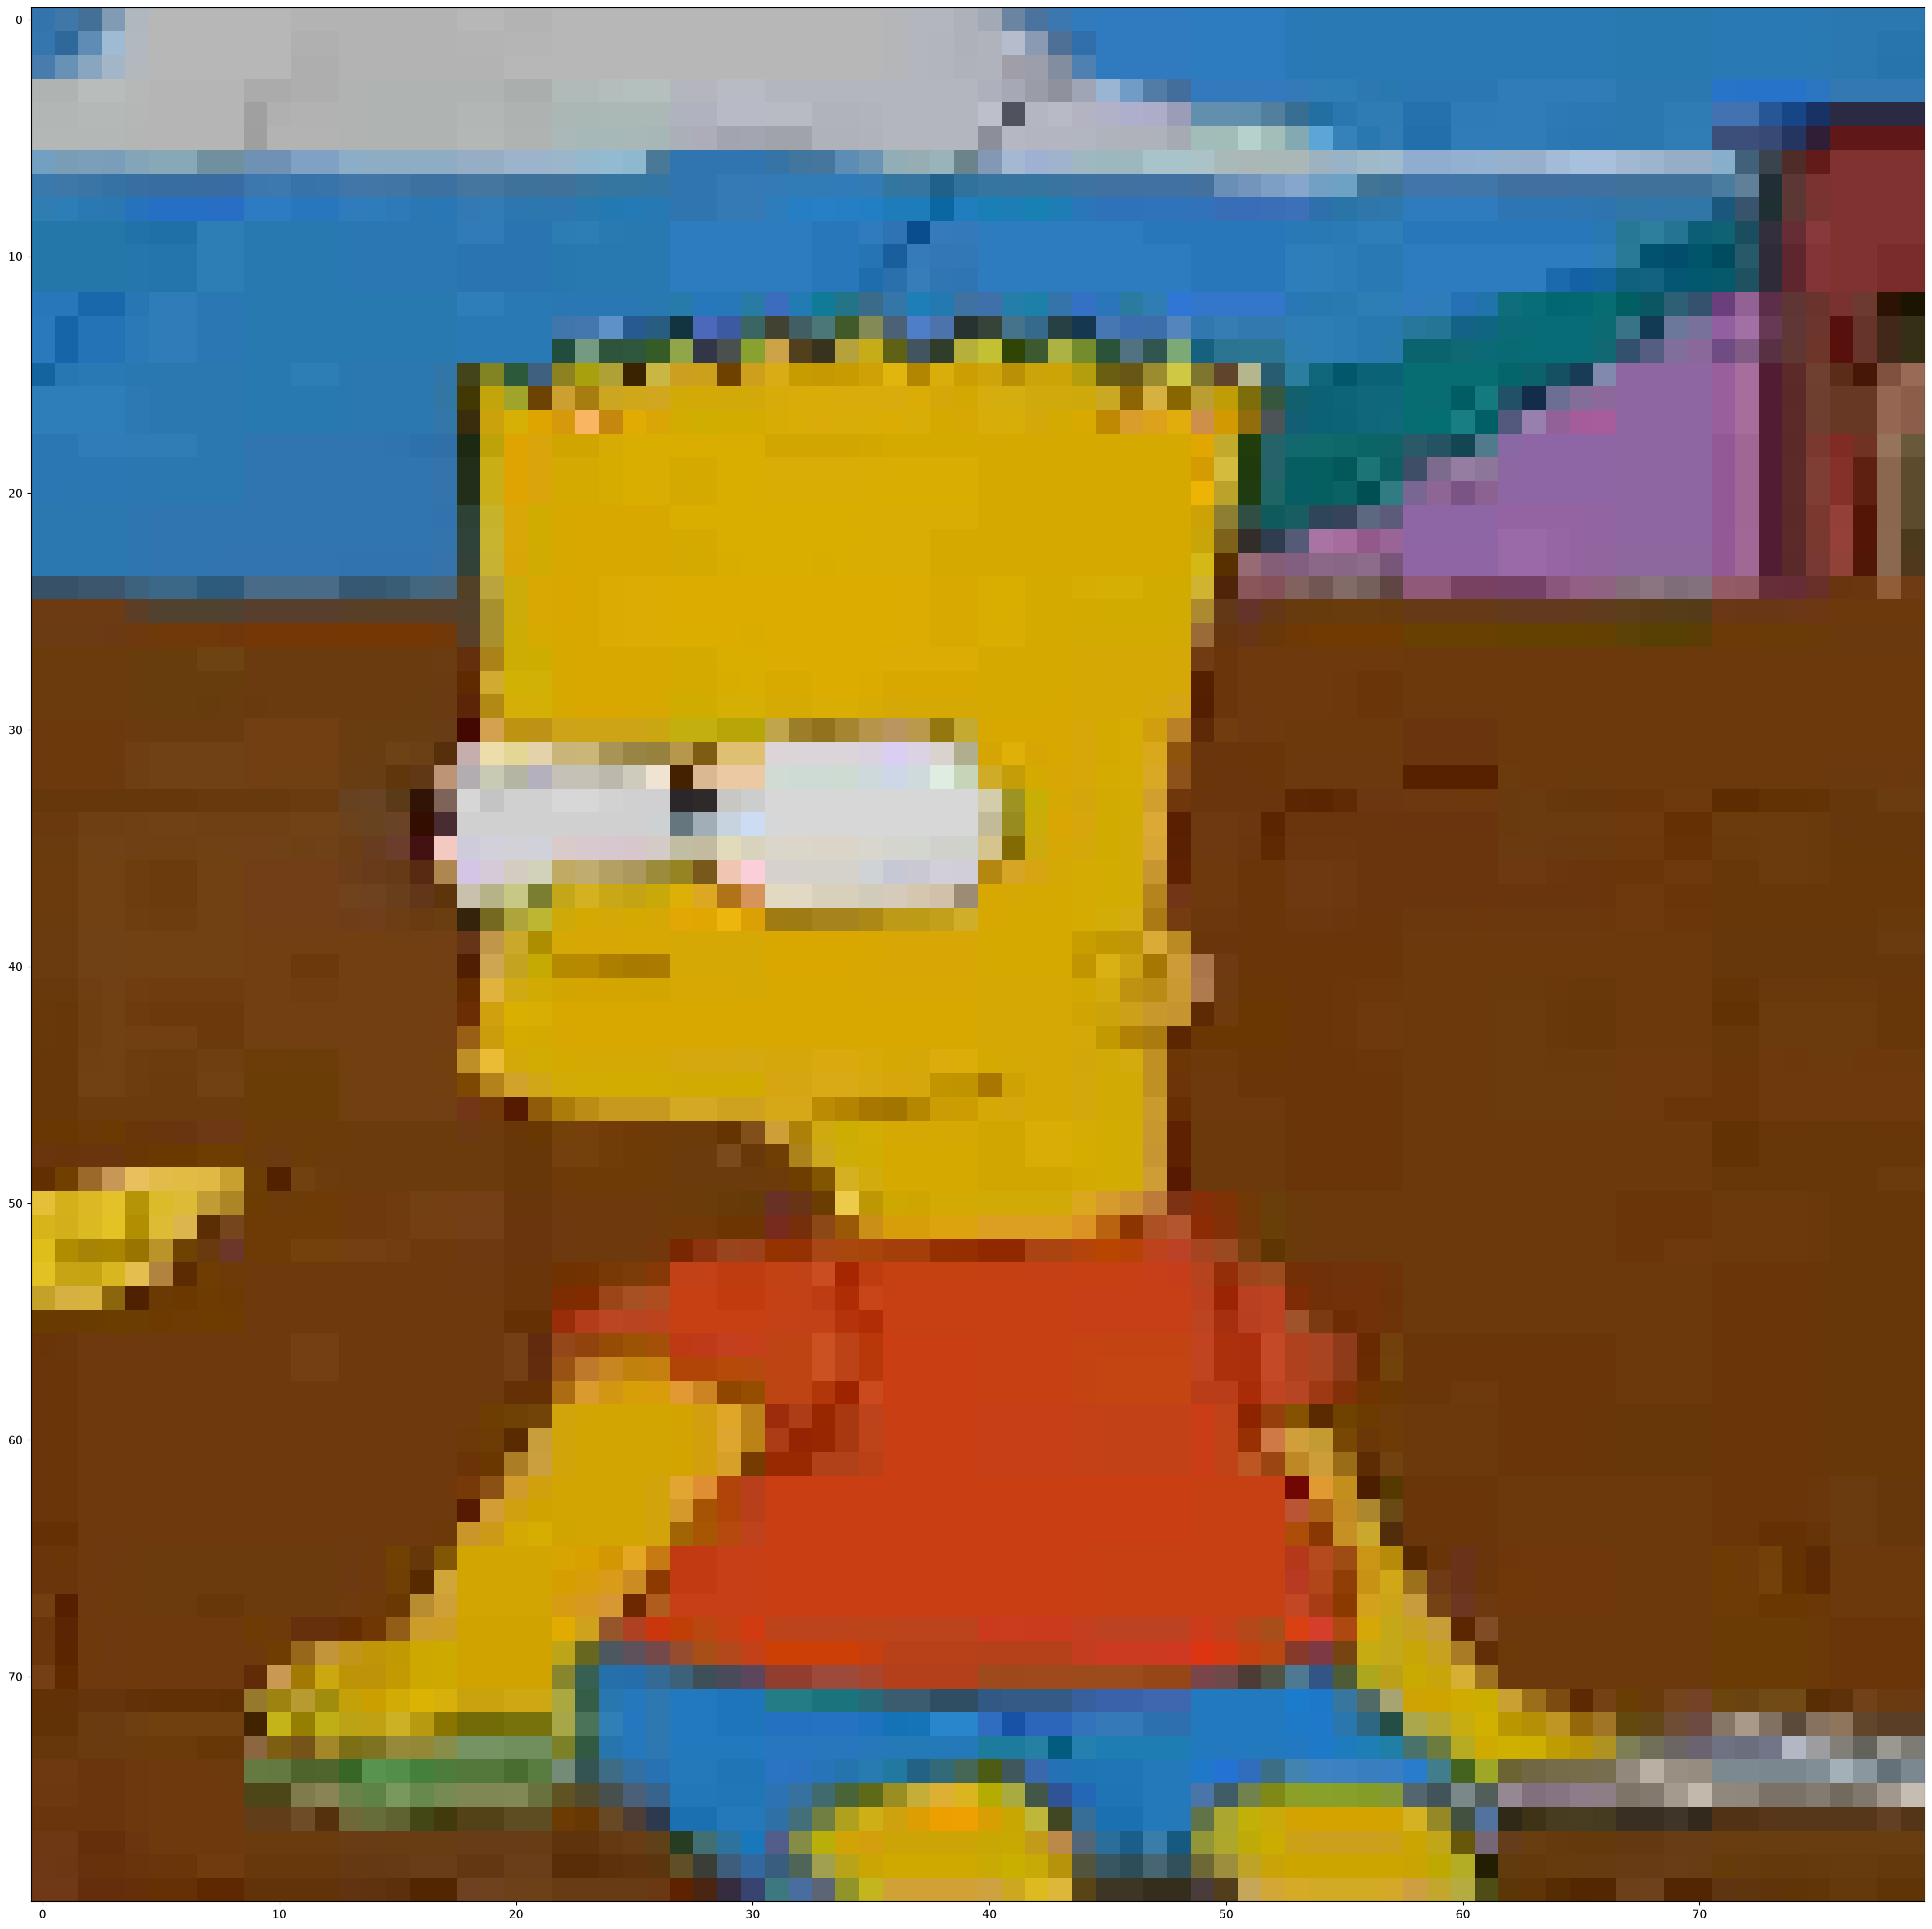

In [96]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 30))
plt.imshow(train[0][0], cmap='gray')
plt.show()

In [97]:
# 1. Ensure 'train' actually has data in it
if 'train' in locals() and len(train) > 0:
    # 2. Re-extract features and labels cleanly
    featureSet = [item[0] for item in train]
    labels = [item[1] for item in train]
    
    print(f"Success! Total Images (X): {len(featureSet)}")
    print(f"Success! Total Labels (y): {len(labels)}")
else:
    print("Error: The 'train' variable is empty. Please re-run your caer.preprocess_from_dir cell first!")

Success! Total Images (X): 13811
Success! Total Labels (y): 13811


In [98]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert lists to rigid numpy arrays so TensorFlow doesn't complain later
X = np.array(featureSet, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

# Perform a perfect, clean 80/20 train/validation split
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shapes:   x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"Validation shapes: x_val: {x_val.shape}, y_val: {y_val.shape}")

Training shapes:   x_train: (11048, 80, 80, 3), y_train: (11048,)
Validation shapes: x_val: (2763, 80, 80, 3), y_val: (2763,)


In [99]:
del train
del featureSet
del labels
gc.collect()

4166

In [100]:
BATCH_SIZE = 32
EPOCHS = 20

In [101]:
import tensorflow as tf

# Modern TensorFlow replacement for imageDataGenerator
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

# Flow the data just like before
train_gen = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE)

In [102]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Automatically scales raw pixel values (0-255) down to (0-1)
    layers.Rescaling(1./255, input_shape=(80, 80, channels)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(124, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(len(characters), activation='softmax') 
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\Xian\tf_env\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [103]:
from tensorflow.keras.callbacks import LearningRateScheduler

# 1. Define a native step-decay function to replace canaro's schedule
def lr_schedule(epoch):
    initial_lr = 0.001
    # Drops the learning rate down by 10% every 5 epochs
    if epoch > 0 and epoch % 5 == 0:
        return initial_lr * (0.1 ** (epoch // 5))
    return initial_lr

# 2. Pass our new native function into the scheduler
callbacks_list = [LearningRateScheduler(lr_schedule)]

In [104]:
training = model.fit(
    train_gen, 
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=callbacks_list
)

Epoch 1/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.3488 - loss: 1.8485 - val_accuracy: 0.5729 - val_loss: 1.3231 - learning_rate: 0.0010
Epoch 2/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.5878 - loss: 1.2452 - val_accuracy: 0.6884 - val_loss: 0.9585 - learning_rate: 0.0010
Epoch 3/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.6822 - loss: 0.9698 - val_accuracy: 0.7459 - val_loss: 0.7983 - learning_rate: 0.0010
Epoch 4/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.7242 - loss: 0.8214 - val_accuracy: 0.7698 - val_loss: 0.7108 - learning_rate: 0.0010
Epoch 5/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.7593 - loss: 0.7065 - val_accuracy: 0.8245 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 6/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.8212 - loss: 0.5444 - val_accuracy: 0.8491 - val_loss: 0.4899 - learning_rate: 1.0000e-04
Epoch 7/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step - accuracy:

In [105]:
characters

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

In [124]:
def prepare(img):
    # 1. CRUCIAL FIX: Convert from BGR to RGB to match caer's training format
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    
    # 2. Resize the color image to (80, 80)
    img = cv.resize(img, IMG_SIZE)
    return img

In [107]:
import random

def predict_random_image(test_dir, character_list, model_instance):
    all_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not all_images:
        print("No images found!")
        return
        
    random_image_name = random.choice(all_images)
    full_path = os.path.join(test_dir, random_image_name)
    
    img = cv.imread(full_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) 
    plt.axis('off')
    plt.show()
    
    # Preprocess the standalone image using our updated function
    processed_img = prepare(img)
    
    # Shape it explicitly into a batch array of shape (1, 80, 80, 1)
    batch_img = np.array([processed_img], dtype=np.float32)
    
    # Predict
    predictions = model_instance.predict(batch_img, verbose=0)
    
    highest_prob_index = np.argmax(predictions[0])
    confidence = predictions[0][highest_prob_index] * 100
    predicted_char = character_list[highest_prob_index]
    
    print(f"File Name: {random_image_name}")
    print(f"Prediction: {predicted_char}")
    print(f"Confidence Level: {confidence:.2f}%")

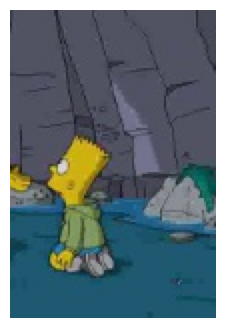

File Name: bart_simpson_49.jpg
Prediction: bart_simpson
Confidence Level: 43.58%


In [182]:
test_directory = os.path.join(path, "kaggle_simpson_testset", "kaggle_simpson_testset")
predict_random_image(test_directory, characters, model)